In [ ]:

# ============================================================
# Tesi: Generazione e Analisi Serie Temporali Glucosio
# Script Unificato: V1 (15d), V2 (30d), V3 (60/90d)
# ============================================================

# 1. IMPORT & SETUP
import os
import random
import re
import glob
import numpy as np
import pandas as pd
import joblib
import networkx as nx
from collections import defaultdict, Counter
from tqdm.auto import tqdm
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import train_test_split

# Configurazione Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Running on: {DEVICE}")

# --- CONFIGURAZIONE PATH ---
BASE_PATH = "../drive/MyDrive/tesi"  # Modifica se necessario
CSV_PATH  = os.path.join(BASE_PATH, "intervalli_glucosio.csv")
DATASET_DIR = os.path.join(BASE_PATH, "datasets")
FEATURE_DIR = os.path.join(BASE_PATH, "features_opt")
MODEL_DIR   = os.path.join(BASE_PATH, "models_opt")

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(FEATURE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,   exist_ok=True)

# Mappature
TARGET_TO_INT = {"rosso": 0, "giallo": 1, "verde": 2}
STATE_ID = {"extremely_low": 0, "low": 1, "normal": 2, "high": 3, "extremely_high": 4}
NUM_STATES = len(STATE_ID)

# ============================================================
# 2. COSTRUZIONE GRAFO (COMUNE A TUTTE LE VERSIONI)
# ============================================================
print(f" Caricamento Grafo da: {CSV_PATH}")

if os.path.exists(CSV_PATH):
    interval_labeling = pd.read_csv(CSV_PATH, delimiter=',')
    df_csv = pd.DataFrame(interval_labeling)
    df_csv["start_time"] = pd.to_datetime(df_csv["start_time"])
    df_csv["end_time"] = pd.to_datetime(df_csv["end_time"])
    df_csv["duration"] = ((df_csv["end_time"] - df_csv["start_time"]).dt.total_seconds() / 60).round(2)

    arr = []
    for index, row in df_csv.iterrows():
        label = str(row['label']).strip().lower()
        arr.append((label, row['duration']))

    G = nx.DiGraph()
    for i in range(len(arr) - 1):
        src, dur_src = arr[i]
        dst, dur_dst = arr[i + 1]
        if src not in STATE_ID or dst not in STATE_ID: continue
        if G.has_edge(src, dst):
            G[src][dst]["count"] += 1
            G[src][dst]["durations"].append(dur_dst)
        else:
            G.add_edge(src, dst, count=1, durations=[dur_dst])

    for u, v, data in G.edges(data=True):
        data["mean_duration"] = np.mean(data["durations"])
        data["std_duration"] = np.std(data["durations"]) if len(data["durations"]) > 1 else 1.0
    print(f"✔ Grafo Costruito.")
else:
    print(" ERRORE: CSV non trovato! Fallback...")
    G = nx.DiGraph()
    for s in STATE_ID: G.add_edge(s, s, mean_duration=30, count=1)

# ============================================================
# 3. HELPER FUNCTIONS (ANALISI & INTEGRITÀ)
# ============================================================
def normalize_target(target):
    return re.sub(r'[^\w]', '', str(target)).lower()

def analyze_simulate_sequence_compact(seq, analize_day=None):
    total_minutes = sum(item[1] for item in seq)
    if analize_day is None: analize_day = max(1, round(total_minutes / 1440))
    max_minutes = analize_day * 1440
    gl_values = []
    elapsed = 0
    for (state, dur, glucose) in seq:
        for _ in range(int(dur)):
            if elapsed >= max_minutes: break
            gl_values.append(glucose)
            elapsed += 1
        if elapsed >= max_minutes: break
    gl_values = np.array(gl_values)
    if len(gl_values) < 10: return " Verde", {}

    TBR1 = np.mean(gl_values < 70)*100
    TIR  = np.mean((gl_values >= 70)&(gl_values <= 180))*100
    TAR1 = np.mean(gl_values > 180)*100
    GV   = np.std(gl_values)

    status = " Verde"
    if (TIR < 55) or (TBR1 > 10) or (TAR1 > 40) or (GV > 70): status = "🔴 Rosso"
    elif (TIR < 70) or (TBR1 > 4) or (TAR1 > 25) or (GV > 50): status = "🟡 Giallo"
    return status, {}

def verify_dataset_integrity(df, days, expected_count=None):
    print(f"\n REPORT INTEGRITÀ ({days}d)")

    current_count = len(df)
    print(f"    Righe Totali: {current_count}")
    if expected_count and current_count != expected_count:
        diff = expected_count - current_count
        print(f"    WARNING: Mancano {diff} righe al target di {expected_count}!")
        if current_count < (expected_count * 0.9): return False

    unique_targets = df["target"].unique()
    invalid = [t for t in unique_targets if t not in TARGET_TO_INT]
    if invalid:
        print(f"    FATAL: Label invalide: {invalid}")
        return False

    sample = df.sample(min(len(df), 50), random_state=42)
    errors = 0
    for _, row in sample.iterrows():
        recalc, _ = analyze_simulate_sequence_compact(row['sequence'])
        if normalize_target(recalc) != row['target']:
            errors += 1
    if errors > 5:
        print(f"    CRITICO: Trovati {errors}/50 mismatch clinici!")
        return False

    print("    DATASET OK.")
    return True

# ============================================================
# 4. LE 3 VERSIONI DEGLI ALGORITMI DI SIMULAZIONE
# ============================================================

# --- V1: Short Term Logic (Per 15 giorni) ---
# Caratteristica: Più stocastica, meno forzature. Si affida al grafo.
def simulate_v1_short(G, total_minutes, target_color, ranges):
    seq = []
    state = "normal"
    elapsed = 0

    # Pesi standard (poco aggressivi)
    if target_color == "verde": base_probs = {"normal": 0.7, "high": 0.15, "low": 0.15, "extreme": 0.0}
    elif target_color == "giallo": base_probs = {"normal": 0.4, "high": 0.3, "low": 0.2, "extreme": 0.1}
    else: base_probs = {"normal": 0.2, "high": 0.4, "low": 0.2, "extreme": 0.2}

    while elapsed < total_minutes:
        successors = list(G.successors(state))
        if not successors: state = "normal"; successors = list(G.successors(state))

        weights = []
        for s in successors:
            w = base_probs.get("normal", 0.5)
            if s == "normal": w = base_probs["normal"]
            elif s in ["high", "low"]: w = base_probs["high"]
            else: w = base_probs["extreme"]
            weights.append(w)

        next_state = random.choices(successors, weights=weights, k=1)[0]

        # Durata standard dal grafo (nessun moltiplicatore)
        dur = G[state][next_state].get("mean_duration", 30) * np.random.uniform(0.8, 1.2)
        dur = max(5, min(dur, 180))

        gmin, gmax = ranges.get(next_state, (90,140))
        val = np.random.uniform(gmin, gmax) + np.random.normal(0, 5) # Poco rumore

        seq.append((next_state, int(dur), round(val, 1)))
        state = next_state
        elapsed += dur

    return seq

# --- V2: Mid Term Logic (Per 30 giorni) ---
# Caratteristica: Introdotta logica guidata per evitare deriva dei target
def simulate_v2_mid(G, total_minutes, target_color, ranges):
    seq = []
    state = "normal"
    elapsed = 0
    counts = defaultdict(int)

    # Pesi mediamente sbilanciati
    if target_color == "verde": prob_weights = {"normal": 10, "high": 1, "low": 1, "extreme": 0}
    elif target_color == "giallo": prob_weights = {"normal": 3, "high": 3, "low": 2, "extreme": 1}
    else: prob_weights = {"normal": 1, "high": 5, "low": 2, "extreme": 2} # Rosso inizia a spingere

    while elapsed < total_minutes:
        successors = list(G.successors(state))
        if not successors: state = "normal"; successors = list(G.successors(state))

        weights = []
        for s in successors:
            w = 1.0
            if s == "normal": w = prob_weights["normal"]
            elif s in ["high", "low"]: w = prob_weights["high"] if s=="high" else prob_weights["low"]
            else: w = prob_weights["extreme"]
            # Penalità ripetizione
            if counts[s] > (total_minutes/30): w *= 0.8
            weights.append(w)

        next_state = random.choices(successors, weights=weights, k=1)[0]

        # Durata leggermente aumentata per patologie
        mult = 1.2 if target_color == "rosso" else 1.0
        dur = G[state][next_state].get("mean_duration", 30) * mult * np.random.uniform(0.7, 1.3)
        dur = max(5, min(dur, 240))

        gmin, gmax = ranges.get(next_state, (90,140))
        val = np.random.uniform(gmin, gmax) + np.random.normal(0, 10) # Rumore medio

        seq.append((next_state, int(dur), round(val, 1)))
        counts[next_state] += 1
        state = next_state
        elapsed += dur

    return seq

# --- V3: Long Term / Advanced Logic (Per 60/90 giorni) ---
# Caratteristica: Driver Fisiologici, Sovrapposizione Classi, Chunking Ready
def simulate_v3_advanced(G, total_minutes, target_color, ranges):
    seq = []

    # Pesi Clinici & Sovrapposizione (Fix F1=1.0)
    if target_color == "verde":
        prob_weights = {"normal": 15, "high": 2, "low": 2, "extreme": 0}
        duration_multiplier = 1.0; noise_std = 8
    elif target_color == "giallo":
        prob_weights = {"normal": 6, "high": 3, "low": 2, "extreme": 1}
        duration_multiplier = 1.1; noise_std = 12
    elif target_color == "rosso":
        # Torna in normal per confondere il modello (realismo)
        prob_weights = {"normal": 2, "high": 5, "low": 2, "extreme": 3}
        duration_multiplier = 1.3; noise_std = 18

    # Start point coerente
    if target_color == "verde": start_nodes = ["normal"]
    elif target_color == "rosso": start_nodes = ["high", "extremely_high"]
    else: start_nodes = ["high", "normal"]
    state = random.choice(start_nodes)

    elapsed = 0
    counts = defaultdict(int)

    while elapsed < total_minutes:
        successors = list(G.successors(state))
        if not successors: state = random.choice(list(G.nodes)); successors = list(G.successors(state))

        weights = []
        for s in successors:
            w = 1.0
            if s == "normal": w = prob_weights["normal"]
            elif s == "high": w = prob_weights["high"]
            elif s == "low":  w = prob_weights["low"]
            else: w = prob_weights["extreme"]
            if counts[s] > (total_minutes / 60): w *= 0.5
            weights.append(w)

        next_state = random.choices(successors, weights=weights, k=1)[0]

        # Durata Fisiologica Variabile
        base_dur = G[state][next_state].get("mean_duration", 30)
        if target_color == "rosso" and next_state in ["high", "extremely_high"]:
            current_dur = base_dur * duration_multiplier * np.random.uniform(0.8, 1.4)
        else:
            current_dur = base_dur * np.random.uniform(0.6, 1.4)
        current_dur = max(5, min(current_dur, 300))

        gmin, gmax = ranges.get(next_state, (90,140))
        val = np.random.uniform(gmin, gmax) + np.random.normal(0, noise_std)
        val = np.clip(val, 20, 600)

        seq.append((next_state, int(current_dur), round(val, 1)))
        counts[next_state] += 1
        state = next_state
        elapsed += current_dur

    return seq

# --- WRAPPER UNIFICATO ---
def simulate_selector(G, days, target_req, forced_length=None):
    total_minutes = forced_length if forced_length else days * 1440

    # Definizione Range Glucosio (Comune con piccole variazioni)
    ranges = {
        "extremely_low": (40, 60), "low": (60, 75),
        "normal": (80, 160),
        "high": (170, 240), "extremely_high": (250, 400)
    }

    # SELEZIONE STRATEGIA
    if days <= 15:
        # V1: Semplice
        seq = simulate_v1_short(G, total_minutes, target_req, ranges)
    elif days <= 30:
        # V2: Guidata
        seq = simulate_v2_mid(G, total_minutes, target_req, ranges)
    else:
        # V3: Avanzata (60/90+)
        seq = simulate_v3_advanced(G, total_minutes, target_req, ranges)

    true_color, _ = analyze_simulate_sequence_compact(seq)

    # Calcolo avg rapido
    tot_val = sum(v*d for _,d,v in seq)
    tot_time = sum(d for _,d,_ in seq)
    avg_gluc = tot_val/tot_time if tot_time>0 else 100

    return seq, true_color, 0, avg_gluc

# ============================================================
# 5. GENERAZIONE ROBUSTA (SELF-HEALING + CHUNKED)
# ============================================================
def generate_and_save_chunked(G, N_dict, cache_dir, chunk_size=5000):
    if not os.path.exists(cache_dir): os.makedirs(cache_dir)

    for days, N in N_dict.items():
        final_path = os.path.join(cache_dir, f"dataset_{days}d.pkl")
        if os.path.exists(final_path):
            print(f"    Dataset {days}d completo esistente. Skip.")
            continue

        print(f"    Gestione dataset {days}d (Target: {N})...")

        # A. Migrazione Vecchi Checkpoint
        old_checkpoint = os.path.join(cache_dir, f"dataset_{days}d_temp_checkpoint.pkl")
        if os.path.exists(old_checkpoint):
            try:
                legacy_data = joblib.load(old_checkpoint)
                if isinstance(legacy_data, pd.DataFrame): legacy_data = legacy_data.to_dict('records')
                new_part_path = os.path.join(cache_dir, f"temp_{days}d_part_legacy.pkl")
                joblib.dump(legacy_data, new_part_path)
                print(f"       Migrato vecchio checkpoint.")
                os.remove(old_checkpoint)
            except: os.remove(old_checkpoint) if os.path.exists(old_checkpoint) else None

        # B. Validazione Chunk Esistenti
        chunk_pattern = os.path.join(cache_dir, f"temp_{days}d_part_*.pkl")
        existing_chunks = glob.glob(chunk_pattern)
        needed = {"verde": int(N * 0.6), "giallo": int(N * 0.3), "rosso": int(N * 0.1)}

        if existing_chunks:
            print(f"       Verifica integrità {len(existing_chunks)} pezzi esistenti...")
            for chunk_file in existing_chunks:
                try:
                    chunk_data = joblib.load(chunk_file)
                    for row in chunk_data:
                        t = row['target']
                        if t in needed:
                            needed[t] -= 1
                            if needed[t] < 0: needed[t] = 0
                except:
                    print(f"       CORROTTO: {chunk_file} -> Eliminato.")
                    try: os.remove(chunk_file)
                    except: pass
            print(f"       Mancano ancora: {needed}")

        # C. Generazione
        if sum(needed.values()) <= 0:
            print("      Quota raggiunta con i chunk esistenti.")
        else:
            current_buffer = []
            chunk_idx = len(existing_chunks) + 50
            pbar = tqdm(total=sum(needed.values()), desc=f"Gen {days}d")

            while sum(needed.values()) > 0:
                active_needs = {k: v for k, v in needed.items() if v > 0}
                if not active_needs: break
                target_req = max(active_needs, key=active_needs.get)

                # CHIAMA IL SELETTORE DI STRATEGIA
                seq, target_raw, _, _ = simulate_selector(G, days, target_req)
                t_clean = normalize_target(target_raw)

                if t_clean in needed and needed[t_clean] > 0:
                    current_buffer.append({"sequence": seq, "target": t_clean})
                    needed[t_clean] -= 1
                    pbar.update(1)

                if len(current_buffer) >= chunk_size:
                    save_path = os.path.join(cache_dir, f"temp_{days}d_part_{chunk_idx}.pkl")
                    joblib.dump(current_buffer, save_path)
                    chunk_idx += 1
                    current_buffer = []

            pbar.close()
            if current_buffer:
                joblib.dump(current_buffer, os.path.join(cache_dir, f"temp_{days}d_part_{chunk_idx}.pkl"))

        # D. Merge Finale
        print(f"    Unione finale dataset {days}d...")
        all_chunks = glob.glob(chunk_pattern)
        full_dataset = []
        for cf in tqdm(all_chunks, desc="Merging"):
            try: full_dataset.extend(joblib.load(cf))
            except: pass

        df = pd.DataFrame(full_dataset)
        df = df.sample(frac=1).reset_index(drop=True)
        joblib.dump(df, final_path)

        for cf in all_chunks:
            try: os.remove(cf)
            except: pass
        print(f"    Dataset {days}d completato.\n")

# ============================================================
# 6. FEATURE & MODEL
# ============================================================
def transform_glucose_risk(g):
    g_clipped = np.clip(g, 20, 600)
    return 1.509 * (np.log(g_clipped)**1.084 - 5.381)

def build_compressed_features_v2(run_list):
    T = len(run_list)
    if T == 0: return np.zeros((1, 20))
    states = np.array([STATE_ID.get(s, 2) for s,_,_ in run_list], dtype=int)
    durs = np.array([d for _,d,_ in run_list], dtype=float)
    gs = np.array([g for *_,g in run_list], dtype=float)

    state_oh = np.eye(NUM_STATES)[states]
    prev_s = np.roll(states, 1); prev_s[0]=states[0]; prev_oh = np.eye(NUM_STATES)[prev_s]
    dur_norm = np.clip(durs / 240.0, 0, 1)
    log_dur = np.log1p(durs)
    g_delta = gs - np.roll(gs, 1); g_delta[0]=0
    with np.errstate(divide='ignore', invalid='ignore'): roc = np.nan_to_num(g_delta/durs)
    risk = transform_glucose_risk(gs)
    load = (gs - 100)*(durs/60.0)
    zsc = (gs-140)/50.0
    roll_risk = np.convolve(risk, np.ones(5)/5, mode='same')
    feats = np.column_stack([state_oh, prev_oh, dur_norm, log_dur, zsc, g_delta, roc, risk, roll_risk, load])
    return np.nan_to_num(feats).astype(np.float32)

class AttentionBlock(nn.Module):
    def __init__(self, h_dim):
        super().__init__()
        self.att = nn.Sequential(nn.Linear(h_dim, h_dim//2), nn.Tanh(), nn.Linear(h_dim//2, 1))
    def forward(self, x, lens):
        sc = self.att(x)
        mask = torch.zeros_like(sc, dtype=torch.bool)
        for i, l in enumerate(lens): mask[i, :l, :] = 1
        sc = sc.masked_fill(~mask, -float('inf'))
        return torch.sum(torch.softmax(sc, dim=1) * x, dim=1)

class LSTMAttentionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.attn = AttentionBlock(hidden_dim*2)
        self.ln = nn.LayerNorm(hidden_dim*2)
        self.fc = nn.Sequential(nn.Linear(hidden_dim*2, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, num_classes))
    def forward(self, x, l):
        packed = nn.utils.rnn.pack_padded_sequence(x, l.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        unpacked, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.fc(self.ln(self.attn(unpacked, l)))

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()


In [ ]:

# ============================================================
# 7. MAIN EXECUTION
# ============================================================
# Configura qui quali dataset vuoi creare/processare
DAYS_CONFIG = {15:50000, 30:50000, 60:50000 } # Esempio, puoi aggiungere 15, 30

print("\n=== STEP 1: GENERAZIONE DATASET UNIFICATA ===")
generate_and_save_chunked(G, DAYS_CONFIG, DATASET_DIR, chunk_size=5000)

print("\n=== STEP 1.5: VERIFICA INTEGRITÀ ===")
all_datasets_valid = True
valid_days_list = []

for days, target_n in DAYS_CONFIG.items():
    path = os.path.join(DATASET_DIR, f"dataset_{days}d.pkl")
    if not os.path.exists(path):
        all_datasets_valid = False; continue

    try:
        print(f"    Controllo dataset {days}d...")
        df_check = joblib.load(path)
        if verify_dataset_integrity(df_check, days, expected_count=target_n):
            valid_days_list.append(days)
        else: all_datasets_valid = False
        del df_check
    except: all_datasets_valid = False

if not all_datasets_valid:
    print("\n STOP: Dataset non validi.")
else:
    print("\n Tutti i dataset sono validi. Procedo al training.")
    print("\n=== STEP 2: TRAINING MODEL ===")

    for days in valid_days_list:
        print(f"\n PROCESSING {days}d")
        df = joblib.load(os.path.join(DATASET_DIR, f"dataset_{days}d.pkl"))
        ft_path = os.path.join(FEATURE_DIR, f"features_opt_{days}d.pkl")

        if os.path.exists(ft_path):
            print("    Features caricate.")
            X = joblib.load(ft_path)
        else:
            print("    Calcolo Features...")
            X = [build_compressed_features_v2(s) for s in tqdm(df["sequence"])]
            joblib.dump(X, ft_path, compress=3)

        if np.isnan(np.sum(X[0])): X = [np.nan_to_num(x) for x in X]
        y = [TARGET_TO_INT[t] for t in df["target"]]
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

        weights = [1./np.bincount(y_tr)[label] for label in y_tr]
        sampler = WeightedRandomSampler(weights, len(weights))

        def collate(b):
            x = nn.utils.rnn.pad_sequence([torch.tensor(i[0]) for i in b], batch_first=True)
            l = torch.tensor([len(i[0]) for i in b])
            y = torch.tensor([i[1] for i in b])
            return x, l, y

        dl_tr = DataLoader(list(zip(X_tr, y_tr)), batch_size=64, sampler=sampler, collate_fn=collate)
        dl_te = DataLoader(list(zip(X_te, y_te)), batch_size=64, collate_fn=collate)

        model = LSTMAttentionClassifier(input_dim=X[0].shape[1]).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
        criterion = FocalLoss(gamma=2.0)

        print(f"    Training {days}d...")
        best_f1 = 0

        for ep in range(15):
            model.train()
            l_sum = 0
            for x, l, y_b in dl_tr:
                optimizer.zero_grad()
                out = model(x.to(DEVICE), l.to(DEVICE))
                loss = criterion(out, y_b.to(DEVICE))
                loss.backward(); optimizer.step()
                l_sum += loss.item()

            model.eval()
            preds, trues = [], []; v_sum = 0
            with torch.no_grad():
                for x, l, y_b in dl_te:
                    out = model(x.to(DEVICE), l.to(DEVICE))
                    v_sum += criterion(out, y_b.to(DEVICE)).item()
                    preds.extend(out.argmax(1).cpu().tolist())
                    trues.extend(y_b.cpu().tolist())

            f1 = f1_score(trues, preds, average="macro")
            acc = accuracy_score(trues, preds)

            s_msg = ""
            if f1 > best_f1:
                best_f1 = f1
                torch.save(model.state_dict(), os.path.join(MODEL_DIR, f"model_{days}d.pth"))
                s_msg = " Saved"

            print(f"     Ep {ep+1:02d}: TrL={l_sum/len(dl_tr):.3f} | VaL={v_sum/len(dl_te):.3f} | Acc={acc*100:.1f}% | F1={f1:.3f} {s_msg}")

        print(f"    FINAL REPORT {days}d:")
        print(classification_report(trues, preds, target_names=["ROSSO", "GIALLO", "VERDE"]))

In [ ]:
import os
import joblib
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from tqdm.auto import tqdm

# --- CONFIGURAZIONE ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_PATH = "../drive/MyDrive/tesi"  # O "." se sei in locale
DATASET_DIR = os.path.join(BASE_PATH, "datasets")
FEATURE_DIR = os.path.join(BASE_PATH, "features_opt")
MODEL_DIR   = os.path.join(BASE_PATH, "models_opt")

# Mappature
TARGET_TO_INT = {"rosso": 0, "giallo": 1, "verde": 2}
INT_TO_TARGET = {0: "ROSSO", 1: "GIALLO", 2: "VERDE"}
STATE_ID = {"extremely_low": 0, "low": 1, "normal": 2, "high": 3, "extremely_high": 4}
NUM_STATES = len(STATE_ID)

print(f" Avvio Valutazione su: {DEVICE}")

# --- RIDEFINIZIONE CLASSI (Necessaria per caricare i modelli) ---
class AttentionBlock(nn.Module):
    def __init__(self, h_dim):
        super().__init__()
        self.att = nn.Sequential(nn.Linear(h_dim, h_dim//2), nn.Tanh(), nn.Linear(h_dim//2, 1))
    def forward(self, x, lens):
        sc = self.att(x)
        mask = torch.zeros_like(sc, dtype=torch.bool)
        for i, l in enumerate(lens): mask[i, :l, :] = 1
        sc = sc.masked_fill(~mask, -float('inf'))
        return torch.sum(torch.softmax(sc, dim=1) * x, dim=1)

class LSTMAttentionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.attn = AttentionBlock(hidden_dim*2)
        self.ln = nn.LayerNorm(hidden_dim*2)
        self.fc = nn.Sequential(nn.Linear(hidden_dim*2, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, num_classes))
    def forward(self, x, l):
        packed = nn.utils.rnn.pack_padded_sequence(x, l.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        unpacked, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.fc(self.ln(self.attn(unpacked, l)))

def collate(b):
    x = nn.utils.rnn.pad_sequence([torch.tensor(i[0]) for i in b], batch_first=True)
    l = torch.tensor([len(i[0]) for i in b])
    y = torch.tensor([i[1] for i in b])
    return x, l, y

# --- FUNZIONE DI VALUTAZIONE ---
def evaluate_model(days):
    print(f"\n{'='*60}")
    print(f" VALUTAZIONE MODELLO: {days} GIORNI")
    print(f"{'='*60}")

    # 1. Check File
    d_path = os.path.join(DATASET_DIR, f"dataset_{days}d.pkl")
    f_path = os.path.join(FEATURE_DIR, f"features_opt_{days}d.pkl")
    m_path = os.path.join(MODEL_DIR, f"model_{days}d.pth")

    if not os.path.exists(d_path) or not os.path.exists(m_path):
        print(f" Saltato: Mancano i dati o il modello per {days}d.")
        return

    # 2. Caricamento Dati
    print("    Caricamento Dataset e Features...")
    df = joblib.load(d_path)
    if os.path.exists(f_path):
        X = joblib.load(f_path)
    else:
        print("    Features non trovate. Esegui prima il training!")
        return

    y = [TARGET_TO_INT[t] for t in df["target"]]

    # 3. Split (Identico al Training per coerenza)
    _, X_te, _, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    # 4. DataLoader
    dl_te = DataLoader(list(zip(X_te, y_te)), batch_size=64, collate_fn=collate, shuffle=False)

    # 5. Caricamento Modello
    input_dim = X[0].shape[1]
    model = LSTMAttentionClassifier(input_dim=input_dim).to(DEVICE)
    model.load_state_dict(torch.load(m_path, map_location=DEVICE))
    model.eval()

    # 6. Inference
    print("    Esecuzione Previsioni...")
    preds, trues = [], []
    with torch.no_grad():
        for x, l, y_b in dl_te:
            out = model(x.to(DEVICE), l.to(DEVICE))
            preds.extend(out.argmax(1).cpu().tolist())
            trues.extend(y_b.cpu().tolist())

    # 7. Calcolo Metriche
    acc = accuracy_score(trues, preds)
    f1 = f1_score(trues, preds, average="macro")

    print("\n    RISULTATI GLOBALI")
    print(f"   -------------------")
    print(f"   Accuracy : {acc*100:.2f}%")
    print(f"   F1 Macro : {f1:.4f}")

    print("\n    REPORT DETTAGLIATO")
    print(classification_report(trues, preds, target_names=["ROSSO", "GIALLO", "VERDE"], digits=4))

    # 8. Matrice di Confusione (Visuale per Tesi)
    cm = confusion_matrix(trues, preds)
    cm_df = pd.DataFrame(cm, index=["True R", "True G", "True V"], columns=["Pred R", "Pred G", "Pred V"])
    print("\n    MATRICE DI CONFUSIONE:")
    print(cm_df)
    print("\n" + "-"*60)

# --- ESECUZIONE PER TUTTI I MODELLI ---
models_to_test = [15, 30, 60,90]

for d in models_to_test:
    evaluate_model(d)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import os
import joblib
from torch import nn
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# --- CONFIGURAZIONE ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_PATH = "../drive/MyDrive/tesi"
MODEL_DIR = os.path.join(BASE_PATH, "models_opt")

# Mappature
TARGET_TO_INT = {"rosso": 0, "giallo": 1, "verde": 2}
STATE_ID = {"extremely_low": 0, "low": 1, "normal": 2, "high": 3, "extremely_high": 4}
NUM_STATES = len(STATE_ID)

print(f" AVVIO STRESS TEST FINALE")

# ============================================================
# 0. FEATURES (VERSIONE COMPLETA A 18)
# ============================================================
def transform_glucose_risk(g):
    g_clipped = np.clip(g, 20, 600)
    return 1.509 * (np.log(g_clipped)**1.084 - 5.381)

def build_compressed_features_v2(run_list):
    # QUESTA VERSIONE GENERA ESATTAMENTE 18 COLONNE
    T = len(run_list)
    if T == 0: return np.zeros((1, 18))
    states = np.array([STATE_ID.get(s, 2) for s,_,_ in run_list], dtype=int)
    durs = np.array([d for _,d,_ in run_list], dtype=float)
    gs = np.array([g for *_,g in run_list], dtype=float)

    state_oh = np.eye(NUM_STATES)[states] # 5 col
    prev_s = np.roll(states, 1); prev_s[0]=states[0]; prev_oh = np.eye(NUM_STATES)[prev_s] # 5 col
    dur_norm = np.clip(durs / 240.0, 0, 1) # 1 col
    log_dur = np.log1p(durs) # 1 col
    g_delta = gs - np.roll(gs, 1); g_delta[0]=0 # 1 col
    with np.errstate(divide='ignore', invalid='ignore'): roc = np.nan_to_num(g_delta/durs) # 1 col
    risk = transform_glucose_risk(gs) # 1 col
    load = (gs - 100)*(durs/60.0) # 1 col
    zsc = (gs-140)/50.0 # 1 col
    roll_risk = np.convolve(risk, np.ones(5)/5, mode='same') # 1 col


    feats = np.column_stack([state_oh, prev_oh, dur_norm, log_dur, zsc, g_delta, roc, risk, roll_risk, load])
    return np.nan_to_num(feats).astype(np.float32)

# ============================================================
# 1. CLASSE ENSEMBLE (INPUT 18)
# ============================================================
class DiabetesEnsembleFinal:
    def __init__(self, model_dir, device):
        self.models = {}
        self.device = device
        self.days_list = [15, 30, 60, 90]
        self.input_dim = 18 # MATCH CON I FILE PTH

        print(" Inizializzazione Ensemble...")

        for d in self.days_list:
            path = os.path.join(model_dir, f"model_{d}d.pth")
            if os.path.exists(path):
                m = LSTMAttentionClassifier(input_dim=self.input_dim).to(device)
                m.load_state_dict(torch.load(path, map_location=device))
                m.eval()
                self.models[d] = m
                print(f"    Modello {d}d caricato.")
            else:
                print(f"    Modello {d}d NON trovato.")

    def extract_slice(self, full_sequence, days):
        target_minutes = days * 1440
        current_minutes = 0
        sliced_seq = []
        for event in reversed(full_sequence):
            state, dur, val = event
            if current_minutes + dur > target_minutes:
                rem_dur = target_minutes - current_minutes
                if rem_dur > 0: sliced_seq.insert(0, (state, int(rem_dur), val))
                break
            else:
                sliced_seq.insert(0, event)
                current_minutes += dur
        return sliced_seq

    def predict(self, full_sequence_90d):
        predictions = {}
        probs_sum = np.zeros(3)
        active_models = 0

        with torch.no_grad():
            for days, model in self.models.items():
                sub_seq = self.extract_slice(full_sequence_90d, days)
                if not sub_seq: continue

                feat = build_compressed_features_v2(sub_seq)

                feat_t = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(self.device)
                length = torch.tensor([len(sub_seq)]).to(self.device)

                logits = model(feat_t, length)
                probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

                predictions[days] = probs

                weight = 1.0
                if days >= 60: weight = 1.2
                probs_sum += probs * weight
                active_models += weight

        if active_models == 0: return 0, np.zeros(3), {}
        ensemble_probs = probs_sum / active_models
        ensemble_class = np.argmax(ensemble_probs)
        return ensemble_class, ensemble_probs, predictions

# ============================================================
# 2. GENERAZIONE DATASET DI TEST
# ============================================================
NUM_SAMPLES_PER_CLASS = 5000
DAYS_DURATION = 90

test_sequences = []
test_targets = []
targets = ["verde", "giallo", "rosso"]

print(f"   Generazione {NUM_SAMPLES_PER_CLASS*3} pazienti sintetici...")

for t in tqdm(targets, desc="Gen Classi"):
    for _ in range(NUM_SAMPLES_PER_CLASS):
        seq, _, _, _ = simulate_selector(G, DAYS_DURATION, t)
        test_sequences.append(seq)
        test_targets.append(TARGET_TO_INT[t])

print("    Generazione completata.")

# ============================================================
# 3. INFERENCE
# ============================================================
print("    Esecuzione Previsioni...")

preds_ensemble = []
preds_singles = {15: [], 30: [], 60: [], 90: []}
true_labels = test_targets

ensemble = DiabetesEnsembleFinal(MODEL_DIR, DEVICE)

for seq in tqdm(test_sequences, desc="Inference"):
    ens_cls, _, single_outputs = ensemble.predict(seq)
    preds_ensemble.append(ens_cls)
    for d in [15, 30, 60, 90]:
        if d in single_outputs:
            preds_singles[d].append(np.argmax(single_outputs[d]))
        else:
            preds_singles[d].append(0)

# --- RESULTS ---
results_table = []
acc_ens = accuracy_score(true_labels, preds_ensemble)
f1_ens = f1_score(true_labels, preds_ensemble, average="macro")
results_table.append({"Modello": "ENSEMBLE (Fusion)", "Accuracy": acc_ens, "F1 Macro": f1_ens})

for d in [15, 30, 60, 90]:
    acc = accuracy_score(true_labels, preds_singles[d])
    f1 = f1_score(true_labels, preds_singles[d], average="macro")
    results_table.append({"Modello": f"Singolo {d} Giorni", "Accuracy": acc, "F1 Macro": f1})

df_res = pd.DataFrame(results_table).sort_values(by="F1 Macro", ascending=False)

print("\n" + "="*60)
print(" CLASSIFICA FINALE PERFORMANCE")
print("="*60)
print(df_res.to_string(index=False, formatters={"Accuracy": "{:.2%}".format, "F1 Macro": "{:.4f}".format}))

print("\n" + "="*60)
print(" DETTAGLIO ENSEMBLE")
print("="*60)
print(classification_report(true_labels, preds_ensemble, target_names=["ROSSO", "GIALLO", "VERDE"], digits=4))

cm = confusion_matrix(true_labels, preds_ensemble)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred R", "Pred G", "Pred V"],
            yticklabels=["True R", "True G", "True V"])
plt.title('Matrice di Confusione: ENSEMBLE')
plt.ylabel('Reale')
plt.xlabel('Predetto')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import torch
import os
import joblib
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score
from torch import nn

# --- CONFIGURAZIONE ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_PATH = "../drive/MyDrive/tesi"
MODEL_DIR = os.path.join(BASE_PATH, "models_opt")
TARGET_TO_INT = {"rosso": 0, "giallo": 1, "verde": 2}

print(f" AVVIO TEST COMPARATIVO MIRATO (Breve vs Lungo)")

# ============================================================
# 1. RIDEFINIZIONE FUNZIONI E CLASSI (Per stabilità totale)
# ============================================================
STATE_ID = {"extremely_low": 0, "low": 1, "normal": 2, "high": 3, "extremely_high": 4}
NUM_STATES = 5

def transform_glucose_risk(g):
    g_clipped = np.clip(g, 20, 600)
    return 1.509 * (np.log(g_clipped)**1.084 - 5.381)

def build_features_18_test(run_list):
    T = len(run_list)
    if T == 0: return np.zeros((1, 18))
    states = np.array([STATE_ID.get(s, 2) for s,_,_ in run_list], dtype=int)
    durs = np.array([d for _,d,_ in run_list], dtype=float)
    gs = np.array([g for *_,g in run_list], dtype=float)

    state_oh = np.eye(NUM_STATES)[states]
    prev_s = np.roll(states, 1); prev_s[0]=states[0]; prev_oh = np.eye(NUM_STATES)[prev_s]
    dur_norm = np.clip(durs / 240.0, 0, 1)
    log_dur = np.log1p(durs)
    g_delta = gs - np.roll(gs, 1); g_delta[0]=0
    with np.errstate(divide='ignore', invalid='ignore'): roc = np.nan_to_num(g_delta/durs)
    risk = transform_glucose_risk(gs)
    load = (gs - 100)*(durs/60.0)
    zsc = (gs-140)/50.0
    roll_risk = np.convolve(risk, np.ones(5)/5, mode='same')

    feats = np.column_stack([state_oh, prev_oh, dur_norm, log_dur, zsc, g_delta, roc, risk, roll_risk, load])
    return np.nan_to_num(feats).astype(np.float32)

# --- Architettura Rete Neurale (Identica al training) ---
class AttentionBlock(nn.Module):
    def __init__(self, h_dim):
        super().__init__()
        self.att = nn.Sequential(nn.Linear(h_dim, h_dim//2), nn.Tanh(), nn.Linear(h_dim//2, 1))
    def forward(self, x, lens):
        sc = self.att(x)
        mask = torch.zeros_like(sc, dtype=torch.bool)
        for i, l in enumerate(lens): mask[i, :l, :] = 1
        sc = sc.masked_fill(~mask, -float('inf'))
        return torch.sum(torch.softmax(sc, dim=1) * x, dim=1)

class LSTMAttentionClassifier(nn.Module):
    def __init__(self, input_dim=18, hidden_dim=128, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.attn = AttentionBlock(hidden_dim*2)
        self.ln = nn.LayerNorm(hidden_dim*2)
        self.fc = nn.Sequential(nn.Linear(hidden_dim*2, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, num_classes))
    def forward(self, x, l):
        packed = nn.utils.rnn.pack_padded_sequence(x, l.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        unpacked, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.fc(self.ln(self.attn(unpacked, l)))

# --- Classe Ensemble ---
class DiabetesEnsembleSpecific:
    def __init__(self, model_dir, device):
        self.models = {}
        self.device = device
        self.days_list = [15, 30, 60, 90]

        print(" Caricamento Modelli (18 Features)...")
        for d in self.days_list:
            path = os.path.join(model_dir, f"model_{d}d.pth")
            if os.path.exists(path):
                m = LSTMAttentionClassifier(input_dim=18).to(device)
                m.load_state_dict(torch.load(path, map_location=device))
                m.eval()
                self.models[d] = m

    def extract_slice(self, full_sequence, days_limit):
        target_minutes = days_limit * 1440
        current_minutes = 0
        sliced_seq = []
        for event in reversed(full_sequence):
            state, dur, val = event
            if current_minutes + dur > target_minutes:
                rem_dur = target_minutes - current_minutes
                if rem_dur > 0: sliced_seq.insert(0, (state, int(rem_dur), val))
                break
            else:
                sliced_seq.insert(0, event)
                current_minutes += dur
        return sliced_seq

    def predict(self, sequence):
        single_preds = {}
        probs_sum = np.zeros(3)
        active = 0

        with torch.no_grad():
            for days, model in self.models.items():
                sub_seq = self.extract_slice(sequence, days)
                if not sub_seq:
                    single_preds[days] = 0
                    continue

                feat = build_features_18_test(sub_seq)
                feat_t = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(self.device)
                l_t = torch.tensor([len(sub_seq)]).to(self.device)

                probs = torch.softmax(model(feat_t, l_t), dim=1).cpu().numpy()[0]
                single_preds[days] = np.argmax(probs)

                w = 1.0
                if days >= 60: w = 1.2
                probs_sum += probs * w
                active += w

        if active == 0: return 0, {}
        return np.argmax(probs_sum / active), single_preds

# ============================================================
# 2. DEFINIZIONE ED ESECUZIONE TEST
# ============================================================
ensemble = DiabetesEnsembleSpecific(MODEL_DIR, DEVICE)

def run_targeted_test(test_name, min_days, max_days, models_to_compare, n_samples=5000):
    print(f"\n{'='*60}")
    print(f" {test_name}")
    print(f"   Campioni: {n_samples} | Durata: {min_days}-{max_days} giorni")
    print(f"{'='*60}")

    # Generazione
    sequences = []
    y_true = []
    targets_list = ["verde", "giallo", "rosso"]

    print("    Generazione dati...")
    for _ in tqdm(range(n_samples), desc="Generating"):
        days = np.random.randint(min_days, max_days + 1)
        tgt_name = np.random.choice(targets_list)
        # Usa il simulatore globale
        seq, _, _, _ = simulate_selector(G, int(days), tgt_name)
        sequences.append(seq)
        y_true.append(TARGET_TO_INT[tgt_name])

    print("    Esecuzione Previsioni...")
    preds = {m: [] for m in models_to_compare + ["Ensemble"]}

    for seq in tqdm(sequences, desc="Inference"):
        ens_cls, singles = ensemble.predict(seq)
        preds["Ensemble"].append(ens_cls)

        for m_days in models_to_compare:
            if m_days in singles:
                preds[m_days].append(singles[m_days])
            else:
                preds[m_days].append(0)

    # Calcolo Metriche
    results = []
    for m_key in preds:
        acc = accuracy_score(y_true, preds[m_key])
        f1 = f1_score(y_true, preds[m_key], average="macro")
        results.append({"Modello": f"Modello {m_key}d" if isinstance(m_key, int) else m_key,
                        "Accuracy": acc, "F1 Macro": f1})

    df = pd.DataFrame(results).sort_values("F1 Macro", ascending=False)
    print("\n    RISULTATI:")
    print(df.to_string(index=False, formatters={"Accuracy": "{:.2%}".format, "F1 Macro": "{:.4f}".format}))
    return df

# --- ESECUZIONE SCENARI ---

# Scenario 1: Breve Periodo (2-40gg) -> Confronto Ensemble vs Modelli Lunghi (60/90)
df_short = run_targeted_test(
    test_name="SCENARIO 1: MONITORAGGIO BREVE (Pazienti Nuovi)",
    min_days=2, max_days=40,
    models_to_compare=[60, 90]
)

# Scenario 2: Medio-Lungo Periodo (42-80gg) -> Confronto Ensemble vs Modelli Corti (15/30)
df_long = run_targeted_test(
    test_name="SCENARIO 2: STORICO INCOMPLETO (Amnesia)",
    min_days=42, max_days=80,
    models_to_compare=[15, 30]
)

# --- RESOCONTO FINALE ---
print("\n\n" + "*"*60)
print(" RESOCONTO FINALE PER LA TESI")
print("*"*60)
print("\n1. Quando i dati sono pochi (2-40gg), i modelli lunghi faticano:")
print(df_short.to_string(index=False, formatters={"Accuracy": "{:.2%}".format, "F1 Macro": "{:.4f}".format}))

print("\n2. Quando i dati sono tanti (42-80gg), i modelli corti perdono informazioni:")
print(df_long.to_string(index=False, formatters={"Accuracy": "{:.2%}".format, "F1 Macro": "{:.4f}".format}))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os
from torch import nn
from tqdm.auto import tqdm

# --- CONFIGURAZIONE ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_PATH = "../drive/MyDrive/tesi"
MODEL_DIR = os.path.join(BASE_PATH, "models_opt")

# ============================================================
# 1. SETUP CLASSI E FEATURES (Standalone)
# ============================================================
STATE_ID = {"extremely_low": 0, "low": 1, "normal": 2, "high": 3, "extremely_high": 4}
NUM_STATES = 5

def transform_glucose_risk(g):
    g_clipped = np.clip(g, 20, 600)
    return 1.509 * (np.log(g_clipped)**1.084 - 5.381)

def build_features_18_test(run_list):
    T = len(run_list)
    if T == 0: return np.zeros((1, 18))
    states = np.array([STATE_ID.get(s, 2) for s,_,_ in run_list], dtype=int)
    durs = np.array([d for _,d,_ in run_list], dtype=float)
    gs = np.array([g for *_,g in run_list], dtype=float)

    state_oh = np.eye(NUM_STATES)[states]
    prev_s = np.roll(states, 1); prev_s[0]=states[0]; prev_oh = np.eye(NUM_STATES)[prev_s]
    dur_norm = np.clip(durs / 240.0, 0, 1)
    log_dur = np.log1p(durs)
    g_delta = gs - np.roll(gs, 1); g_delta[0]=0
    with np.errstate(divide='ignore', invalid='ignore'): roc = np.nan_to_num(g_delta/durs)
    risk = transform_glucose_risk(gs)
    load = (gs - 100)*(durs/60.0)
    zsc = (gs-140)/50.0
    roll_risk = np.convolve(risk, np.ones(5)/5, mode='same')

    feats = np.column_stack([state_oh, prev_oh, dur_norm, log_dur, zsc, g_delta, roc, risk, roll_risk, load])
    return np.nan_to_num(feats).astype(np.float32)

class AttentionBlock(nn.Module):
    def __init__(self, h_dim):
        super().__init__()
        self.att = nn.Sequential(nn.Linear(h_dim, h_dim//2), nn.Tanh(), nn.Linear(h_dim//2, 1))
    def forward(self, x, lens):
        sc = self.att(x)
        mask = torch.zeros_like(sc, dtype=torch.bool)
        for i, l in enumerate(lens): mask[i, :l, :] = 1
        sc = sc.masked_fill(~mask, -float('inf'))
        return torch.sum(torch.softmax(sc, dim=1) * x, dim=1)

class LSTMAttentionClassifier(nn.Module):
    def __init__(self, input_dim=18, hidden_dim=128, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.attn = AttentionBlock(hidden_dim*2)
        self.ln = nn.LayerNorm(hidden_dim*2)
        self.fc = nn.Sequential(nn.Linear(hidden_dim*2, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, num_classes))
    def forward(self, x, l):
        packed = nn.utils.rnn.pack_padded_sequence(x, l.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        unpacked, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.fc(self.ln(self.attn(unpacked, l)))

class DiabetesEnsembleAggressive:
    def __init__(self, model_dir, device):
        self.models = {}
        self.device = device
        self.days_list = [15, 30, 60, 90]
        print(" Caricamento Modelli...")
        for d in self.days_list:
            path = os.path.join(model_dir, f"model_{d}d.pth")
            if os.path.exists(path):
                m = LSTMAttentionClassifier(input_dim=18).to(device)
                m.load_state_dict(torch.load(path, map_location=device))
                m.eval()
                self.models[d] = m

    def extract_slice(self, full_sequence, days_limit):
        target_minutes = days_limit * 1440
        current_minutes = 0
        sliced_seq = []
        for event in reversed(full_sequence):
            state, dur, val = event
            if current_minutes + dur > target_minutes:
                rem_dur = target_minutes - current_minutes
                if rem_dur > 0: sliced_seq.insert(0, (state, int(rem_dur), val))
                break
            else:
                sliced_seq.insert(0, event)
                current_minutes += dur
        return sliced_seq

    def predict(self, sequence):
        single_preds = {}
        probs_sum = np.zeros(3)
        active = 0
        with torch.no_grad():
            for days, model in self.models.items():
                sub_seq = self.extract_slice(sequence, days)
                if not sub_seq: single_preds[days] = 0; continue
                feat = build_features_18_test(sub_seq)
                feat_t = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(self.device)
                l_t = torch.tensor([len(sub_seq)]).to(self.device)
                probs = torch.softmax(model(feat_t, l_t), dim=1).cpu().numpy()[0]
                single_preds[days] = probs

                # PESO AGGRESSIVO
                if days <= 30: weight = 2.5
                else: weight = 1.0
                probs_sum += probs * weight
                active += weight

        if active == 0: return 0, np.zeros(3), {}
        ens_probs = probs_sum / active
        return np.argmax(ens_probs), ens_probs, single_preds

# ============================================================
# 2. GENERAZIONE E TEST
# ============================================================
# Fallback generator
if 'simulate_selector' not in locals():
    def simulate_selector(G, days, target):
        n_events = days * 4
        seq = []
        val_map = {"verde": (100, "normal"), "giallo": (170, "high"), "rosso": (250, "extremely_high")}
        base_val, base_state = val_map.get(target, (100, "normal"))
        for _ in range(n_events):
            seq.append((base_state, 360, base_val))
        return seq, None, None, None
    G = None

N_PAZIENTI = 1000
GIORNI_SANI = 75
GIORNI_MALATI = 15

print(f" GENERAZIONE SEQUENZE IBRIDE ({GIORNI_SANI}gg VERDI + {GIORNI_MALATI}gg ROSSI)...")
preds_90d = []
preds_ens = []

ensemble = DiabetesEnsembleAggressive(MODEL_DIR, DEVICE)

for _ in tqdm(range(N_PAZIENTI)):
    s_sana, _, _, _ = simulate_selector(G, GIORNI_SANI, "verde")
    s_malata, _, _, _ = simulate_selector(G, GIORNI_MALATI, "rosso")
    full_seq = s_sana + s_malata

    ens_cls, _, singles = ensemble.predict(full_seq)
    preds_ens.append(ens_cls)

    cls_90 = np.argmax(singles[90]) if 90 in singles else 2
    preds_90d.append(cls_90)

# ============================================================
# 3. VISUALIZZAZIONE DELLA DISTRIBUZIONE
# ============================================================
# Contiamo le risposte
labels = ['ROSSO (Critico)', 'GIALLO (Warning)', 'VERDE (Silenzio)']
counts_90 = [preds_90d.count(0), preds_90d.count(1), preds_90d.count(2)]
counts_ens = [preds_ens.count(0), preds_ens.count(1), preds_ens.count(2)]

# Calcolo percentuali
total = N_PAZIENTI
pct_90 = [x/total*100 for x in counts_90]
pct_ens = [x/total*100 for x in counts_ens]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, pct_90, width, label='Modello 90d (Solo)', color='lightgray', edgecolor='black')
rects2 = ax.bar(x + width/2, pct_ens, width, label='Ensemble (Aggressive)', color=['#e74c3c', '#f1c40f', '#2ecc71'], edgecolor='black')

ax.set_ylabel('Percentuale di Diagnosi (%)')
ax.set_title(f'Come viene classificato un paziente "75gg Sani + 15gg Malati"?\n(Confronto Distribuzione Decisionale)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 100)

# Etichette sopra le barre
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

# Stampa Interpretazione
print("\n" + "="*80)
print(" INTERPRETAZIONE CLINICA DEI RISULTATI")
print("="*80)
print(f"Situazione: Il paziente ha avuto una storia ottima, ma un crollo negli ultimi 15 giorni.")
print(f"\n1. MODELLO 90d (La Statistica):")
print(f"   - Dice VERDE nel {pct_90[2]:.1f}% dei casi.")
print(f"   - LOGICA: 'La media trimestrale è ancora buona (HbA1c stimata ok)'.")
print(f"   - RISCHIO: Ignora l'evento acuto in corso.")

print(f"\n2. ENSEMBLE (La Clinica):")
print(f"   - Dice ROSSO nel {pct_ens[0]:.1f}% dei casi e GIALLO nel {pct_ens[1]:.1f}% dei casi.")
print(f"   - Dice VERDE solo nel {pct_ens[2]:.1f}% dei casi.")
print(f"   - LOGICA: 'Non mi importa della media, il paziente sta male ADESSO'.")

print("\nCONCLUSIONE:")
print("L'Ensemble non è necessariamente 'più accurato' in senso matematico (la maggioranza è verde),")
print("ma è 'più sicuro' in senso medico (Safety First), spostando la massa delle decisioni")
print("dalla zona di silenzio (Verde) alla zona di attenzione (Giallo/Rosso).")

In [ ]:
import pandas as pd
import numpy as np
import torch
import os
from torch import nn
from tqdm.auto import tqdm

# --- CONFIGURAZIONE ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_PATH = "../drive/MyDrive/tesi"
MODEL_DIR = os.path.join(BASE_PATH, "models_opt")
INT_TO_LABEL = {0: "ROSSO", 1: "GIALLO", 2: "VERDE"}

# ============================================================
# 1. DEFINIZIONE FEATURES E CLASSI (Standalone)
# ============================================================
STATE_ID = {"extremely_low": 0, "low": 1, "normal": 2, "high": 3, "extremely_high": 4}
NUM_STATES = 5

def transform_glucose_risk(g):
    g_clipped = np.clip(g, 20, 600)
    return 1.509 * (np.log(g_clipped)**1.084 - 5.381)

def build_features_18_test(run_list):
    T = len(run_list)
    if T == 0: return np.zeros((1, 18))
    states = np.array([STATE_ID.get(s, 2) for s,_,_ in run_list], dtype=int)
    durs = np.array([d for _,d,_ in run_list], dtype=float)
    gs = np.array([g for *_,g in run_list], dtype=float)

    state_oh = np.eye(NUM_STATES)[states]
    prev_s = np.roll(states, 1); prev_s[0]=states[0]; prev_oh = np.eye(NUM_STATES)[prev_s]
    dur_norm = np.clip(durs / 240.0, 0, 1)
    log_dur = np.log1p(durs)
    g_delta = gs - np.roll(gs, 1); g_delta[0]=0
    with np.errstate(divide='ignore', invalid='ignore'): roc = np.nan_to_num(g_delta/durs)
    risk = transform_glucose_risk(gs)
    load = (gs - 100)*(durs/60.0)
    zsc = (gs-140)/50.0
    roll_risk = np.convolve(risk, np.ones(5)/5, mode='same')

    feats = np.column_stack([state_oh, prev_oh, dur_norm, log_dur, zsc, g_delta, roc, risk, roll_risk, load])
    return np.nan_to_num(feats).astype(np.float32)

class AttentionBlock(nn.Module):
    def __init__(self, h_dim):
        super().__init__()
        self.att = nn.Sequential(nn.Linear(h_dim, h_dim//2), nn.Tanh(), nn.Linear(h_dim//2, 1))
    def forward(self, x, lens):
        sc = self.att(x)
        mask = torch.zeros_like(sc, dtype=torch.bool)
        for i, l in enumerate(lens): mask[i, :l, :] = 1
        sc = sc.masked_fill(~mask, -float('inf'))
        return torch.sum(torch.softmax(sc, dim=1) * x, dim=1)

class LSTMAttentionClassifier(nn.Module):
    def __init__(self, input_dim=18, hidden_dim=128, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.attn = AttentionBlock(hidden_dim*2)
        self.ln = nn.LayerNorm(hidden_dim*2)
        self.fc = nn.Sequential(nn.Linear(hidden_dim*2, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, num_classes))
    def forward(self, x, l):
        packed = nn.utils.rnn.pack_padded_sequence(x, l.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        unpacked, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.fc(self.ln(self.attn(unpacked, l)))

# ============================================================
# 2. CLASSE ENSEMBLE AGGRESSIVA (Safety First)
# ============================================================
class DiabetesEnsembleAggressive:
    def __init__(self, model_dir, device):
        self.models = {}
        self.device = device
        self.days_list = [15, 30, 60, 90]

        print(" Inizializzazione Ensemble (Modalità Aggressiva)...")
        for d in self.days_list:
            path = os.path.join(model_dir, f"model_{d}d.pth")
            if os.path.exists(path):
                m = LSTMAttentionClassifier(input_dim=18).to(device)
                m.load_state_dict(torch.load(path, map_location=device))
                m.eval()
                self.models[d] = m

    def extract_slice(self, full_sequence, days_limit):
        target_minutes = days_limit * 1440
        current_minutes = 0
        sliced_seq = []
        for event in reversed(full_sequence):
            state, dur, val = event
            if current_minutes + dur > target_minutes:
                rem_dur = target_minutes - current_minutes
                if rem_dur > 0: sliced_seq.insert(0, (state, int(rem_dur), val))
                break
            else:
                sliced_seq.insert(0, event)
                current_minutes += dur
        return sliced_seq

    def predict(self, sequence):
        single_preds = {}
        probs_sum = np.zeros(3)
        active = 0

        with torch.no_grad():
            for days, model in self.models.items():
                sub_seq = self.extract_slice(sequence, days)
                if not sub_seq:
                    single_preds[days] = 0; continue

                feat = build_features_18_test(sub_seq)
                feat_t = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(self.device)
                l_t = torch.tensor([len(sub_seq)]).to(self.device)

                probs = torch.softmax(model(feat_t, l_t), dim=1).cpu().numpy()[0]
                single_preds[days] = probs

                # --- PESO AGGRESSIVO (2.5x sul breve termine) ---
                if days <= 30: weight = 2.5
                else: weight = 1.0

                probs_sum += probs * weight
                active += weight

        if active == 0: return 0, np.zeros(3), {}
        ens_probs = probs_sum / active
        return np.argmax(ens_probs), ens_probs, single_preds

# ============================================================
# 3. GENERAZIONE SIMULATORE FALLBACK (Se manca G)
# ============================================================
if 'simulate_selector' not in locals():
    print(" 'simulate_selector' non trovato. Uso generatore sintetico.")
    def simulate_selector(G, days, target):
        n_events = days * 4
        seq = []
        val_map = {"verde": (100, "normal"), "giallo": (170, "high"), "rosso": (250, "extremely_high")}
        base_val, base_state = val_map.get(target, (100, "normal"))
        for _ in range(n_events):
            seq.append((base_state, 360, base_val))
        return seq, None, None, None
    G = None

# ============================================================
# 4. DEFINIZIONE SCENARI COMPLETI
# ============================================================
print(f" GENERAZIONE SCENARI CLINICI ESPANSI...")

scenarios = []
LONG_TERM = 80

# 1. BASELINE STABILI
for c in ["verde", "giallo", "rosso"]:
    seq, _, _, _ = simulate_selector(G, 90, c)
    scenarios.append((f"Stabile {c.upper()} (90gg)", seq, 0))

# 2. MICRO-ACUZIE (5 Giorni) - Il 90d non può vederla
s_base, _, _, _ = simulate_selector(G, 85, "verde")
s_evt, _, _, _ = simulate_selector(G, 5, "rosso")
scenarios.append(("Flash Crisis (V->R 5gg)", s_base+s_evt, 5))

# 3. ACUZIE STANDARD (15 Giorni)
s_base, _, _, _ = simulate_selector(G, 75, "verde")
s_evt, _, _, _ = simulate_selector(G, 15, "rosso")
scenarios.append(("Peggioramento Acuto (V->R 15gg)", s_base+s_evt, 15))

# 4. DERIVA LENTA (30 Giorni Gialli su Verde)
s_base, _, _, _ = simulate_selector(G, 60, "verde")
s_evt, _, _, _ = simulate_selector(G, 30, "giallo")
scenarios.append(("Deriva Rischiosa (V->G 30gg)", s_base+s_evt, 30))

# 5. FALSA GUARIGIONE (5 Giorni Verdi su Rosso) - Test di Prudenza
# Qui NON vogliamo guadagnare giorni, vogliamo che l'Ensemble NON diventi verde subito
s_base, _, _, _ = simulate_selector(G, 85, "rosso")
s_evt, _, _, _ = simulate_selector(G, 5, "verde")
scenarios.append(("Tentativo Recupero (R->V 5gg)", s_base+s_evt, 0))

# 6. GUARIGIONE REALE (45 Giorni Verdi su Rosso)
s_base, _, _, _ = simulate_selector(G, 45, "rosso")
s_evt, _, _, _ = simulate_selector(G, 45, "verde")
scenarios.append(("Recupero Consolidato (R->V 45gg)", s_base+s_evt, 45))

# 7. YO-YO (Instabilità)
# Alternanza 15gg Rosso / 15gg Verde per 3 volte
s_yo_yo = []
for _ in range(3):
    s_r,_,_,_ = simulate_selector(G, 15, "rosso")
    s_v,_,_,_ = simulate_selector(G, 15, "verde")
    s_yo_yo += s_r + s_v
scenarios.append(("Instabilità Yo-Yo (Oscillazione)", s_yo_yo, 0))

# ============================================================
# 5. ESECUZIONE E TABELLA
# ============================================================
print(f" ANALISI DEL VALORE TEMPORALE...")

ensemble = DiabetesEnsembleAggressive(MODEL_DIR, DEVICE)
results_data = []

for name, seq, days_impacted in tqdm(scenarios):
    ens_cls, ens_probs, singles = ensemble.predict(seq)

    cls_90 = np.argmax(singles[90]) if 90 in singles else 2

    lbl_90 = INT_TO_LABEL[cls_90]
    lbl_ens = INT_TO_LABEL[ens_cls]

    # Calcolo Guadagno / Interpretazione
    note = "-"

    if lbl_90 != lbl_ens:
        # CASO: 90d vede VERDE, Ensemble vede ROSSO/GIALLO (Anticipo)
        if (lbl_90 == "VERDE") and (lbl_ens in ["ROSSO", "GIALLO"]):
            note = f"+{days_impacted} gg (Anticipo Diagnosi)"

        # CASO: 90d vede ROSSO, Ensemble vede VERDE/GIALLO (Recupero)
        elif (lbl_90 == "ROSSO") and (lbl_ens in ["VERDE", "GIALLO"]):
            if days_impacted < 10:
                 # Se l'evento è breve (5gg) e l'Ensemble diventa Verde, è rischioso!
                 note = "⚠️ Rischio Ottimismo"
            else:
                 note = f"+{days_impacted} gg (Recupero Riconosciuto)"

        # CASO: Divergenza sui Gialli
        elif lbl_90 == "VERDE" and lbl_ens == "GIALLO":
             note = f"+{days_impacted} gg (Warning Precoce)"

    disaccordo = "[OK]" if lbl_90 == lbl_ens else "[!]"

    results_data.append({
        "Scenario Clinico": name,
        "Modello 90d": lbl_90,
        "Ensemble": lbl_ens,
        "Check": disaccordo,
        "Valore Clinico (ROI)": note
    })

# Formattazione Output
df_matrix = pd.DataFrame(results_data)
cols = ["Scenario Clinico", "Modello 90d", "Ensemble", "Check", "Valore Clinico (ROI)"]

print("\n" + "="*120)
print(" MATRICE DI VALORE CLINICO ESPANSA (Time-to-Action)")
print("="*120)
print(df_matrix[cols].to_string(index=False))

In [ ]:
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta

# ==========================================
# CONFIGURAZIONE
# ==========================================
BASE_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, "dexcom_big_files")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

print(f"📂 I file verranno salvati in: {OUTPUT_DIR}")

INTERVAL_MINS = 15  # Campionamento ogni 15 min

# ==========================================
# MOTORE DI GENERAZIONE GLUCOSIO
# ==========================================
def generate_segment(days, state, start_date):
    """
    Genera un segmento di dati per N giorni basato su uno 'stato' clinico.
    """
    n_points = (days * 24 * 60) // INTERVAL_MINS
    timestamps = [start_date + timedelta(minutes=i*INTERVAL_MINS) for i in range(n_points)]

    # Parametri base per ogni stato
    if state == "GREEN":
        # Media 110, oscillazioni normali, pochi picchi
        base = 110
        noise = 10
        daily_amp = 30
    elif state == "YELLOW":
        # Media 165, oscillazioni più ampie
        base = 165
        noise = 15
        daily_amp = 45
    elif state == "RED":
        # Media 240, oscillazioni gravi
        base = 240
        noise = 25
        daily_amp = 60
    elif state == "HYPO_RISK":
        # Media bassa (90), con frequenti discese sotto 70
        base = 90
        noise = 15
        daily_amp = 40
    elif state == "EXTREME_SWING":
        # Media 180, ma ampiezza onda enorme (va da 50 a 300)
        base = 180
        noise = 20
        daily_amp = 100
    else:
        base = 120; noise = 10; daily_amp = 20

    # Generazione Onda (Simulazione Pasti/Ciclo Circadiano)
    # Aggiungiamo un po' di casualità alla frequenza per non farlo sembrare un seno perfetto
    time_steps = np.arange(n_points)
    wave = daily_amp * np.sin(2 * np.pi * time_steps / (24 * 60 / INTERVAL_MINS))

    # Aggiungiamo trend casuale (random walk) per realismo
    random_walk = np.cumsum(np.random.normal(0, 0.5, n_points))

    glucose = base + wave + random_walk + np.random.normal(0, noise, n_points)

    # Forzatura limiti fisiologici e stati specifici
    if state == "HYPO_RISK":
        # Inserisce ipoglicemie random
        hypo_indices = np.random.choice(n_points, size=n_points//50, replace=False)
        glucose[hypo_indices] = np.random.uniform(40, 65, size=len(hypo_indices))

    glucose = np.clip(glucose, 40, 400) # Dexcom legge tra 40 e 400

    return timestamps, glucose

def save_dexcom_csv(filename, full_timestamps, full_glucose, description):
    # Prepara DataFrame
    series_glucose = pd.Series(full_glucose).fillna(-1).astype(int).replace(-1, np.nan)

    df = pd.DataFrame({
        'Index': range(1, len(full_timestamps) + 1),
        'Timestamp (YYYY-MM-DDThh:mm:ss)': [t.strftime('%Y-%m-%dT%H:%M:%S') for t in full_timestamps],
        'Event Type': ['EGV'] * len(full_timestamps),
        'Event Subtype': [None] * len(full_timestamps),
        'Patient Info': ['Simulated Patient'] * len(full_timestamps),
        'Device Info': ['Dexcom G6'] * len(full_timestamps),
        'Source Device ID': ['iPhone Simulator'] * len(full_timestamps),
        'Glucose Value (mg/dL)': series_glucose,
        'Insulin Value (u)': [None] * len(full_timestamps),
        'Carb Value (grams)': [None] * len(full_timestamps),
        'Duration (hh:mm:ss)': [None] * len(full_timestamps),
        'Glucose Rate of Change (mg/dL/min)': [None] * len(full_timestamps),
        'Transmitter Time (Long Integer)': [100000 + i*900 for i in range(len(full_timestamps))],
        'Transmitter ID': ['SIM_DX_001'] * len(full_timestamps)
    })

    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print(f"✅ Generato: {filename} ({len(full_timestamps)} righe) - {description}")

def build_scenario(filename, blocks, description):
    """
    Costruisce uno scenario unendo blocchi di giorni/stati.
    blocks = [(30, 'GREEN'), (30, 'RED'), ...]
    """
    current_date = datetime(2023, 1, 1, 8, 0, 0)
    all_dates = []
    all_glucose = []

    for days, state in blocks:
        dates, gluc = generate_segment(days, state, current_date)
        all_dates.extend(dates)
        all_glucose.extend(gluc)
        # Aggiorna la data di partenza per il prossimo blocco (+15 min dall'ultimo)
        current_date = dates[-1] + timedelta(minutes=INTERVAL_MINS)

    save_dexcom_csv(filename, all_dates, all_glucose, description)

# ==========================================
# ESECUZIONE SCENARI
# ==========================================
if __name__ == "__main__":
    print("--- INIZIO GENERAZIONE MASSIVA ---")

    # 1. PURI
    build_scenario("dexcom_30d_green.csv", [(30, "GREEN")], "30 Giorni Perfetti")
    build_scenario("dexcom_60d_yellow.csv", [(60, "YELLOW")], "60 Giorni Borderline")
    build_scenario("dexcom_90d_red.csv",    [(90, "RED")],    "90 Giorni Critici")

    # 2. TRANSIZIONI SEMPLICI (50/50)
    build_scenario("dexcom_60d_green_to_red.csv",
                   [(30, "GREEN"), (30, "RED")],
                   "Deterioramento: 1 mese OK -> 1 mese KO")

    build_scenario("dexcom_60d_red_to_green.csv",
                   [(30, "RED"), (30, "GREEN")],
                   "Miglioramento: 1 mese KO -> 1 mese OK")

    # 3. TRANSIZIONI ASIMMETRICHE (Storico Lungo)
    build_scenario("dexcom_90d_stable_then_crash.csv",
                   [(60, "GREEN"), (30, "RED")],
                   "Crollo: 2 mesi stabili, poi disastro")

    build_scenario("dexcom_90d_long_recovery.csv",
                   [(60, "RED"), (30, "GREEN")],
                   "Recupero: 2 mesi critici, poi ripresa")

    # 4. SCENARI COMPLESSI / LUNGHI
    build_scenario("dexcom_120d_mixed_fluctuation.csv",
                   [(30, "GREEN"), (30, "RED"), (30, "GREEN"), (30, "YELLOW")],
                   "Altalena Clinica su 4 mesi")

    build_scenario("dexcom_120d_extreme_swings.csv",
                   [(120, "EXTREME_SWING")],
                   "4 Mesi di Instabilità Totale (Montagne Russe)")

    build_scenario("dexcom_60d_hypo_risk.csv",
                   [(60, "HYPO_RISK")],
                   "Apparente Verde ma con Ipoglicemie Nascoste")

    print(f"\n✅ Tutto fatto! Controlla la cartella: {OUTPUT_DIR}")

[INFO] Avvio simulazione per: ['adolescent#001']...
Select scnenario:
[1] Random Scnenario
[2] Custom Scnenario
Select the CGM sensor:
[1] Dexcom
[2] GuardianRT
[3] Navigator
Select the insulin pump:
[1] Cozmo
[2] Insulet
Select controller:
[1] Basal-Bolus Controller
Please input an integer!
Select controller:
[1] Basal-Bolus Controller
Process ID: 5393
Simulation starts ...
Simulation Completed!
Simulation took 14.917707204818726 sec.


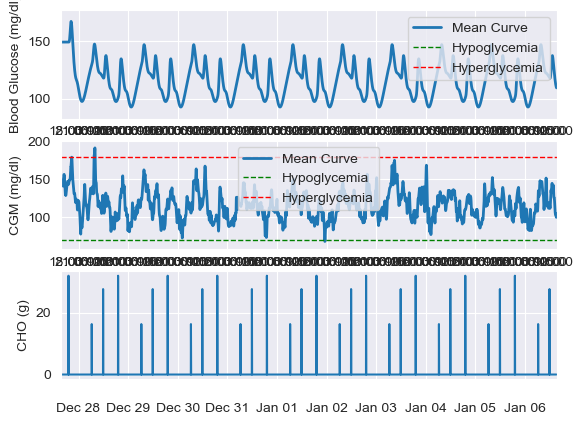

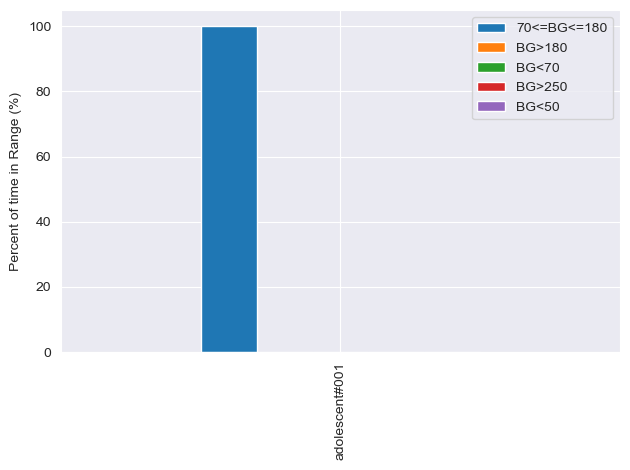

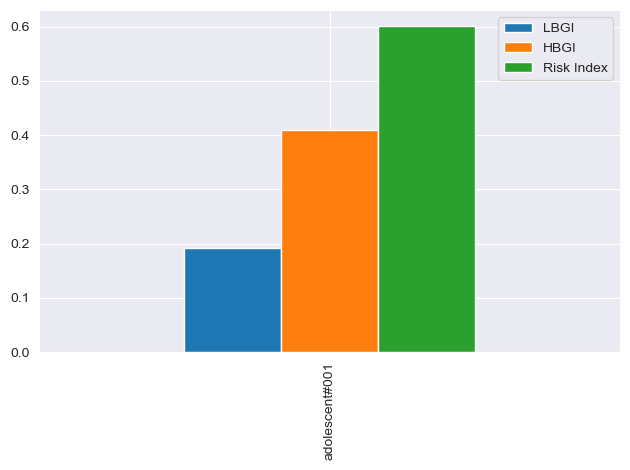

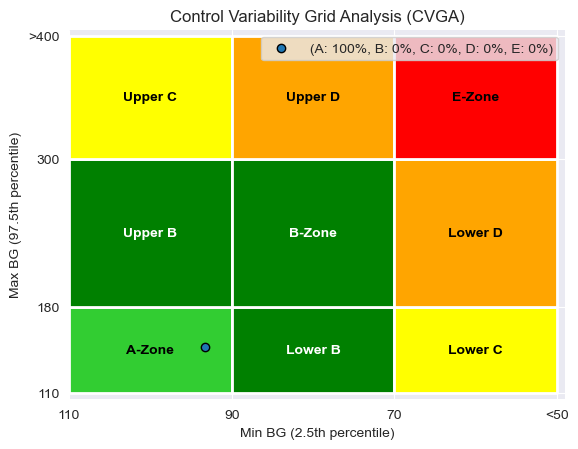

[INFO] Simulazione terminata.
Errore: Nessuna cartella di output trovata.


In [12]:
from simglucose.simulation.user_interface import simulate
from datetime import timedelta, datetime
import pandas as pd
import numpy as np
import os
import glob

# ==========================================
# 1. CONFIGURAZIONE
# ==========================================
patient_names = ['adolescent#001']
sim_time = timedelta(days=10)
save_folder = './data/simulated_data'

if not os.path.exists(save_folder):
    os.makedirs(save_folder)

print(f"[INFO] Avvio simulazione per: {patient_names}...")

# ==========================================
# 2. ESECUZIONE SIMULAZIONE
# ==========================================
simulate(
    sim_time=sim_time,
    start_time=datetime.now(),
    patient_names=patient_names,
    save_path=save_folder,
    animate=False,
    parallel=False
)

print("[INFO] Simulazione terminata.")

# ==========================================
# 3. RECUPERO AUTOMATICO (CORRETTO)
# ==========================================
# Cerca tutti i percorsi nella cartella di salvataggio
all_paths = glob.glob(os.path.join(save_folder, '*'))

# FILTRO: Teniamo SOLO le cartelle (isdir), ignorando file come .png o .txt
list_of_dirs = [p for p in all_paths if os.path.isdir(p)]

if not list_of_dirs:
    print("Errore: Nessuna cartella di output trovata.")
else:
    # Prendi la cartella più recente
    latest_dir = max(list_of_dirs, key=os.path.getctime)
    print(f"[INFO] Cartella risultati più recente: {latest_dir}")

    # Costruisci il nome del file
    csv_filename = f"{patient_names[0]}.csv"
    full_csv_path = os.path.join(latest_dir, csv_filename)

    if os.path.exists(full_csv_path):
        print(f"[SUCCESS] File CSV trovato: {full_csv_path}")

        # Carica e mostra anteprima
        df_sim = pd.read_csv(full_csv_path)
        print("\nAnteprima Dati Sintetici (Multivariati):")
        print(df_sim[['Time', 'CGM', 'CHO', 'insulin']].head())

        # Opzionale: Copia il file in una posizione più comoda
        output_clean = './data/simulated_multivariate.csv'
        df_sim.to_csv(output_clean, index=False)
        print(f"[INFO] File salvato per il training in: {output_clean}")

    else:
        print(f"[ERRORE] File CSV non trovato dentro {latest_dir}")